In [2]:
# =========================
# CELL 1: LOAD DATA + GROUPS
# =========================

import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import pandas as pd
import os

# ---- PATH ----
phy_path = r"D:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2\recording1\continuous\Neuropix-PXI-107.ProbeA\kilosort4"

# ---- LOAD ----
sorting = se.read_phy(phy_path)

cg_path = os.path.join(phy_path, "cluster_group.tsv")
df = pd.read_csv(cg_path, sep="\t")

unit_ids_all = sorting.get_unit_ids()
sf = sorting.get_sampling_frequency()

# ---- GROUPS ----
good_cluster_ids = set(df[df["group"] == "good"]["cluster_id"].values)
noise_cluster_ids = set(df[df["group"] == "noise"]["cluster_id"].values)

good_units = [u for u in unit_ids_all if u in good_cluster_ids]
noise_units = [u for u in unit_ids_all if u in noise_cluster_ids]

sorting_good = sorting.select_units(good_units)
sorting_noise = sorting.select_units(noise_units)

print(f"✅ Good units: {len(good_units)}")
print(f"⚠️ Noise units: {len(noise_units)}")

# =========================
# LOAD NI TTL + SELECT PIN
# =========================

import numpy as np
import os

# ---- SET PATH ----
ni_folder = r"D:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2\recording1\events\NI-DAQmx-106.PXIe-6341\TTL"   #################################################################################################################################################

# ---- SELECT TTL PIN ----
TTL_PIN = 7   # 👈 CHANGE THIS (0–15 typically)   ###############################################################################################################

print("Using NI folder:")
print(ni_folder)
print(f"Using TTL pin: {TTL_PIN}")

# ---- LOAD FILES ----
timestamps_path = os.path.join(ni_folder, "timestamps.npy")
states_path     = os.path.join(ni_folder, "states.npy")
full_words_path = os.path.join(ni_folder, "full_words.npy")

if not os.path.exists(full_words_path):
    print("❌ TTL files not found")

else:
    timestamps_ni = np.load(timestamps_path)
    states_ni     = np.load(states_path)
    full_words_ni = np.load(full_words_path)

    print("✅ TTL data loaded")
    print("Samples:", len(full_words_ni))
    print("Duration (s):", timestamps_ni[-1] - timestamps_ni[0])

    # =========================
    # EXTRACT SPECIFIC TTL CHANNEL
    # =========================
    bit_mask = 1 << TTL_PIN

    ttl_signal = (full_words_ni & bit_mask) > 0  # boolean signal

    # ---- FIND RISING EDGES ----
    ttl_diff = np.diff(ttl_signal.astype(int))

    rising_edges = np.where(ttl_diff == 1)[0] + 1

    ttl_times_all = timestamps_ni[rising_edges] # ✅ keep original

    ttl_times = ttl_times_all.copy()  # working variable

    print(f"⏱️ Extracted {len(ttl_times_all)} TTL events from pin {TTL_PIN}")

    print(f"⏱️ Extracted {len(ttl_times)} TTL events from pin {TTL_PIN}")

# =========================
# TTL REFRACTORY FILTER
# =========================

min_interval = 1.0  # seconds (your choice)

filtered_ttl_times = []
last_kept_time = -np.inf

for t in ttl_times:
    if t - last_kept_time >= min_interval:
        filtered_ttl_times.append(t)
        last_kept_time = t

filtered_ttl_times = np.array(filtered_ttl_times)

print(f"\n🧹 TTL filtering applied (min interval = {min_interval}s)")
print(f"Original TTLs: {len(ttl_times)}")
print(f"Filtered TTLs: {len(filtered_ttl_times)}")

# overwrite for downstream analysis
ttl_times = filtered_ttl_times

C:\Users\Kevin\AppData\Local\miniconda3\envs\spikeinterface_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Good units: 185
⚠️ Noise units: 252
Using NI folder:
D:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2\recording1\events\NI-DAQmx-106.PXIe-6341\TTL
Using TTL pin: 7
✅ TTL data loaded
Samples: 470598
Duration (s): 1991.7090666666668
⏱️ Extracted 48 TTL events from pin 7
⏱️ Extracted 48 TTL events from pin 7

🧹 TTL filtering applied (min interval = 1.0s)
Original TTLs: 48
Filtered TTLs: 48


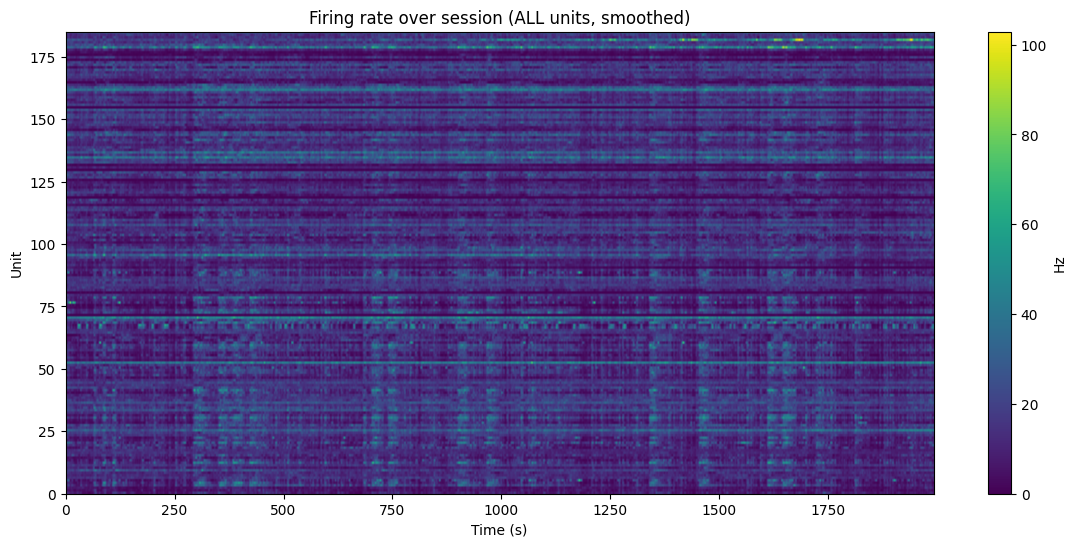

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

bin_size = 1 ###############################################################################################################################################################################################
SMOOTH_SIGMA = 1.5  # lighter than original #################################################################################################################################################################

# -------------------------
# get duration
# -------------------------
all_spike_times = []

for unit in good_units:
    st = sorting_good.get_unit_spike_train(unit) / sf
    if len(st) > 0:
        all_spike_times.append(st[-1])

recording_duration = np.max(all_spike_times)

# -------------------------
# bins
# -------------------------
bins = np.arange(0, recording_duration + bin_size, bin_size)
centers = (bins[:-1] + bins[1:]) / 2

rate_matrix = []

# -------------------------
# firing rates (ALL units)
# -------------------------
for unit in good_units:

    spike_times = sorting_good.get_unit_spike_train(unit) / sf

    counts, _ = np.histogram(spike_times, bins=bins)
    rate = counts / bin_size

    rate_smooth = gaussian_filter1d(rate, sigma=SMOOTH_SIGMA)

    rate_matrix.append(rate_smooth)

rate_matrix = np.array(rate_matrix)

# -------------------------
# PLOT ONLY
# -------------------------
plt.figure(figsize=(14,6))

plt.imshow(rate_matrix,
           aspect='auto',
           extent=[0, recording_duration, 0, len(good_units)],
           origin='lower')

plt.xlabel("Time (s)")
plt.ylabel("Unit")
plt.title("Firing rate over session (ALL units, smoothed)")
plt.colorbar(label="Hz")

plt.show()

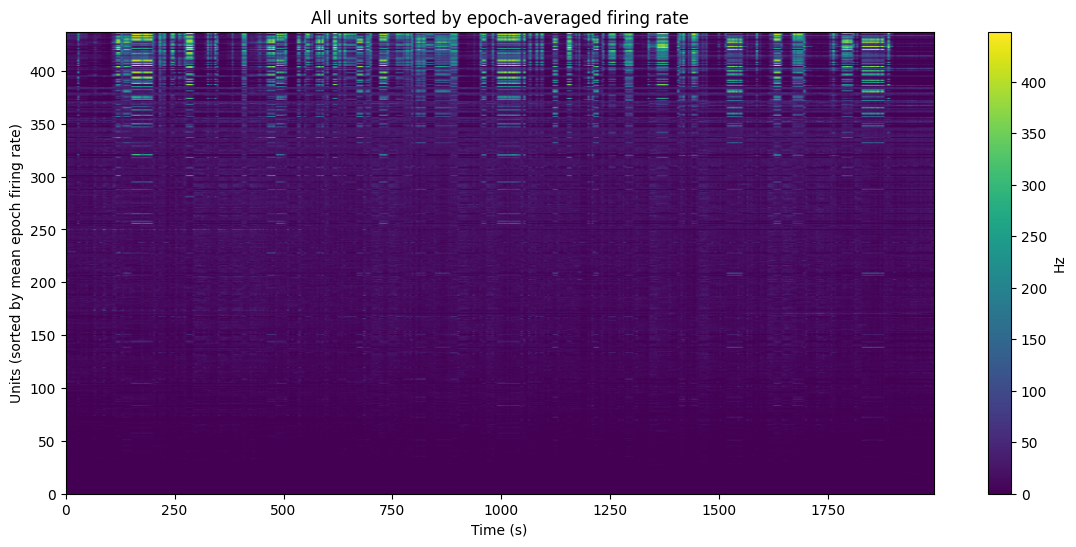

In [5]:
#----------------------------------------------------------------------------#
######### EPOCH AVERAGED GLOBAL FIRING RATE SORTED BY ACTIVITY ##########
#----------------------------------------------------------------------------#

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# =========================
# PARAMETERS
# =========================
bin_size = 1.0   #############################################################################################################################################################################
SMOOTH_SIGMA = 1.5   #########################################################################################################################################################################
N_EPOCHS = 5   # 👈 key change (you can tune this)#################################################################################################################################################

# =========================
# COMBINE UNITS
# =========================
all_units = good_units + noise_units

# =========================
# GET RECORDING DURATION
# =========================
max_time = 0
for unit in all_units:
    st = sorting.get_unit_spike_train(unit) / sf
    if len(st) > 0:
        max_time = max(max_time, st[-1])

recording_duration = max_time

# =========================
# BUILD TIME BINS
# =========================
bins = np.arange(0, recording_duration + bin_size, bin_size)
centers = (bins[:-1] + bins[1:]) / 2

# =========================
# FUNCTION: FIRING MATRIX
# =========================
def build_rate_matrix(units):
    mat = []

    for unit in units:
        st = sorting.get_unit_spike_train(unit) / sf

        counts, _ = np.histogram(st, bins=bins)
        rate = counts / bin_size
        rate = gaussian_filter1d(rate, SMOOTH_SIGMA)

        mat.append(rate)

    return np.array(mat)

rate_matrix = build_rate_matrix(all_units)

# =========================
# EPOCH-BASED FIRING RATE
# =========================
epoch_edges = np.linspace(0, rate_matrix.shape[1], N_EPOCHS + 1, dtype=int)

epoch_rates = []

for i in range(rate_matrix.shape[0]):
    unit_epoch_means = []

    for e in range(N_EPOCHS):
        start = epoch_edges[e]
        end = epoch_edges[e + 1]

        epoch_mean = np.mean(rate_matrix[i, start:end])
        unit_epoch_means.append(epoch_mean)

    epoch_rates.append(np.mean(unit_epoch_means))

epoch_rates = np.array(epoch_rates)

# =========================
# SORT UNITS BY STABLE FIRING RATE
# =========================
order = np.argsort(epoch_rates)
rate_matrix_sorted = rate_matrix[order]
sorted_units = [all_units[i] for i in order]

# =========================
# PLOT
# =========================
plt.figure(figsize=(14,6))

plt.imshow(rate_matrix_sorted,
           aspect='auto',
           extent=[0, recording_duration, 0, len(all_units)],
           origin='lower')

plt.xlabel("Time (s)")
plt.ylabel("Units (sorted by mean epoch firing rate)")
plt.title("All units sorted by epoch-averaged firing rate")
plt.colorbar(label="Hz")

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# =========================
# PARAMETERS
# =========================
bin_size = 3.0 #########################################################################################################################################################################
SMOOTH_SIGMA = 1.5 #########################################################################################################################################################################

EPOCH_LEN = 20.0   # seconds #########################################################################################################################################################################
N_EPOCHS = 5       # random samples per neuron #######################################################################################################################################################

# =========================
# GET DURATION
# =========================
max_time = 0
for unit in good_units:
    st = sorting.get_unit_spike_train(unit) / sf
    if len(st) > 0:
        max_time = max(max_time, st[-1])

recording_duration = max_time

# =========================
# TIME BINS
# =========================
bins = np.arange(0, recording_duration + bin_size, bin_size)

# =========================
# BUILD FIRING MATRIX (GOOD ONLY)
# =========================
rate_matrix = []
robust_mean_rates = []

for unit in good_units:

    st = sorting.get_unit_spike_train(unit) / sf

    counts, _ = np.histogram(st, bins=bins)
    rate = counts / bin_size
    rate = gaussian_filter1d(rate, SMOOTH_SIGMA)

    rate_matrix.append(rate)

    # -------------------------
    # RANDOM EPOCH SAMPLING
    # -------------------------
    epoch_means = []

    for _ in range(N_EPOCHS):

        start = np.random.uniform(0, recording_duration - EPOCH_LEN)
        end = start + EPOCH_LEN

        start_bin = np.searchsorted(bins, start)
        end_bin = np.searchsorted(bins, end)

        epoch_mean = np.mean(rate[start_bin:end_bin])
        epoch_means.append(epoch_mean)

    robust_mean_rates.append(np.mean(epoch_means))

rate_matrix = np.array(rate_matrix)
robust_mean_rates = np.array(robust_mean_rates)

# =========================
# SORT (HIGH → LOW)
# =========================
order = np.argsort(robust_mean_rates)[::-1]

rate_sorted = rate_matrix[order]
sorted_units = np.array(good_units)[order]

# =========================
# PLOT
# =========================
plt.figure(figsize=(14,6))

plt.imshow(rate_sorted,
           aspect='auto',
           extent=[0, recording_duration, 0, len(good_units)],
           origin='lower')

plt.xlabel("Time (s)")
plt.ylabel("GOOD units (sorted by robust epoch FR)")
plt.title("GOOD units sorted by random-epoch firing rate estimate")
plt.colorbar(label="Hz")

plt.show()

Recording duration: 1992.00 sec

🚨 Units with large firing rate changes:
(threshold = 3.0x baseline)
Unit 0 | baseline=7.90 Hz | high=17.34 | low=2.60 | ↑x2.19 ↓x3.04
Unit 3 | baseline=6.04 Hz | high=12.42 | low=1.69 | ↑x2.06 ↓x3.56
Unit 4 | baseline=6.36 Hz | high=11.80 | low=1.86 | ↑x1.86 ↓x3.42
Unit 11 | baseline=12.01 Hz | high=36.62 | low=2.41 | ↑x3.05 ↓x4.98
Unit 13 | baseline=9.68 Hz | high=32.39 | low=2.31 | ↑x3.34 ↓x4.19
Unit 27 | baseline=15.12 Hz | high=45.94 | low=5.37 | ↑x3.04 ↓x2.82
Unit 29 | baseline=9.91 Hz | high=27.74 | low=3.20 | ↑x2.80 ↓x3.10
Unit 32 | baseline=5.25 Hz | high=16.99 | low=2.92 | ↑x3.24 ↓x1.79
Unit 41 | baseline=9.38 Hz | high=25.53 | low=3.03 | ↑x2.72 ↓x3.10
Unit 42 | baseline=15.43 Hz | high=27.80 | low=3.92 | ↑x1.80 ↓x3.94
Unit 44 | baseline=19.03 Hz | high=42.24 | low=5.58 | ↑x2.22 ↓x3.41
Unit 48 | baseline=8.65 Hz | high=36.45 | low=3.00 | ↑x4.21 ↓x2.88
Unit 59 | baseline=5.88 Hz | high=24.71 | low=2.32 | ↑x4.20 ↓x2.53
Unit 60 | baseline=8.51 Hz 

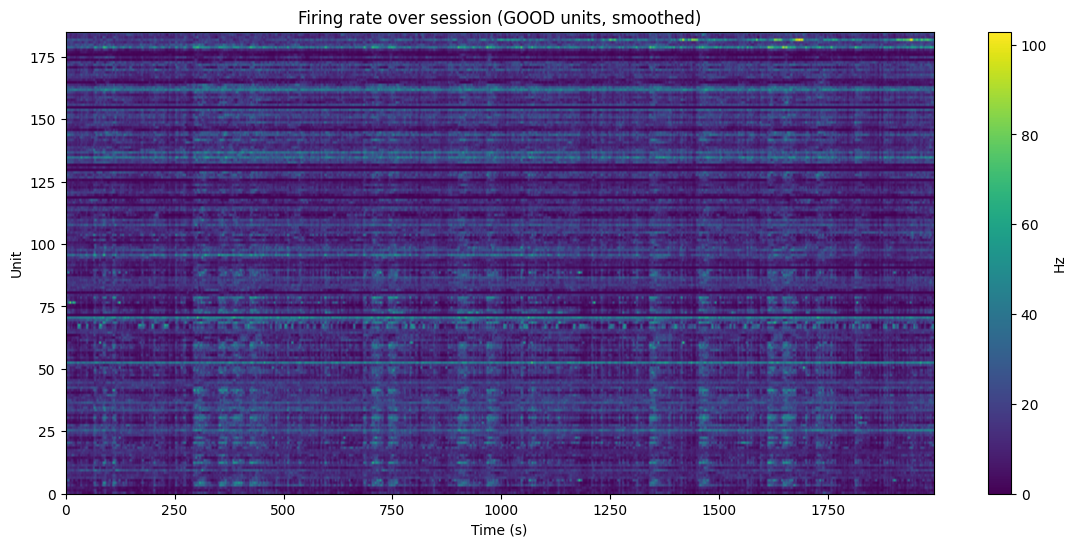

In [6]:
# =========================
# CELL: FIRING RATE (ROBUST)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---- PARAMETERS ----
bin_size = 1.0          # 👈 bigger bins (was 1.0)    #####################################################################
SMOOTH_SIGMA = 1.5      # 👈 light smoothing          #####################################################################
BASELINE_END = 100.0    # baseline window             #####################################################################
THRESHOLD = 3.0         # stricter threshold           #####################################################################

# =========================
# RECORDING DURATION
# =========================
all_spike_times = []

for unit in good_units:
    st = sorting_good.get_unit_spike_train(unit) / sf
    if len(st) > 0:
        all_spike_times.append(st[-1])

recording_duration = np.max(all_spike_times)
print(f"Recording duration: {recording_duration:.2f} sec")

# =========================
# BINNING
# =========================
bins = np.arange(0, recording_duration + bin_size, bin_size)
centers = (bins[:-1] + bins[1:]) / 2

rate_matrix = []

# =========================
# COMPUTE FIRING RATES
# =========================
for unit in good_units:

    spike_times = sorting_good.get_unit_spike_train(unit) / sf

    counts, _ = np.histogram(spike_times, bins=bins)
    rate = counts / bin_size

    # 👇 smoothing (critical)
    rate_smooth = gaussian_filter1d(rate, sigma=SMOOTH_SIGMA)

    rate_matrix.append(rate_smooth)

rate_matrix = np.array(rate_matrix)

# =========================
# BASELINE (FIRST 100s)
# =========================
baseline_mask = centers <= BASELINE_END
baseline_rates = np.mean(rate_matrix[:, baseline_mask], axis=1)

# =========================
# DETECT LARGE CHANGES (ROBUST)
# =========================
flagged_units = []

for i, unit in enumerate(good_units):

    baseline = baseline_rates[i]

    # 👇 robust stats (ignore extremes)
    high = np.percentile(rate_matrix[i], 95)
    low  = np.percentile(rate_matrix[i], 5)

    if baseline < 0.1:
        continue

    fold_up = high / baseline
    fold_down = baseline / max(low, 0.1)

    if (fold_up >= THRESHOLD) or (fold_down >= THRESHOLD):
        flagged_units.append((unit, baseline, high, low, fold_up, fold_down))

print("\n🚨 Units with large firing rate changes:")
print(f"(threshold = {THRESHOLD}x baseline)")

for u in flagged_units[:20]:
    print(f"Unit {u[0]} | baseline={u[1]:.2f} Hz | high={u[2]:.2f} | low={u[3]:.2f} | ↑x{u[4]:.2f} ↓x{u[5]:.2f}")

print(f"\nTotal flagged units: {len(flagged_units)} / {len(good_units)}")

# =========================
# PLOT HEATMAP
# =========================

plt.figure(figsize=(14,6))

plt.imshow(rate_matrix,
           aspect='auto',
           extent=[0, recording_duration, 0, len(good_units)],
           origin='lower')

plt.xlabel("Time (s)")
plt.ylabel("Unit")
plt.title("Firing rate over session (GOOD units, smoothed)")
plt.colorbar(label="Hz")

Recording duration: 1992.00 sec

🚨 Units with large firing rate changes:
(threshold = 3.0x baseline)
Unit 48 | baseline=8.62 Hz | high=32.32 | low=4.49 | ↑x3.75 ↓x1.92
Unit 59 | baseline=5.84 Hz | high=21.84 | low=3.61 | ↑x3.74 ↓x1.62
Unit 60 | baseline=8.44 Hz | high=28.08 | low=5.38 | ↑x3.33 ↓x1.57
Unit 62 | baseline=8.97 Hz | high=27.66 | low=5.83 | ↑x3.08 ↓x1.54
Unit 91 | baseline=6.50 Hz | high=27.04 | low=3.26 | ↑x4.16 ↓x1.99
Unit 93 | baseline=12.58 Hz | high=40.85 | low=8.13 | ↑x3.25 ↓x1.55
Unit 133 | baseline=10.33 Hz | high=24.15 | low=3.42 | ↑x2.34 ↓x3.02
Unit 155 | baseline=16.74 Hz | high=29.32 | low=5.06 | ↑x1.75 ↓x3.31
Unit 164 | baseline=0.15 Hz | high=0.67 | low=0.01 | ↑x4.48 ↓x1.50
Unit 181 | baseline=3.33 Hz | high=11.76 | low=0.93 | ↑x3.53 ↓x3.58
Unit 182 | baseline=19.34 Hz | high=28.91 | low=5.79 | ↑x1.49 ↓x3.34
Unit 189 | baseline=0.79 Hz | high=3.97 | low=0.03 | ↑x5.02 ↓x7.91
Unit 191 | baseline=12.85 Hz | high=18.27 | low=3.02 | ↑x1.42 ↓x4.26
Unit 201 | baselin

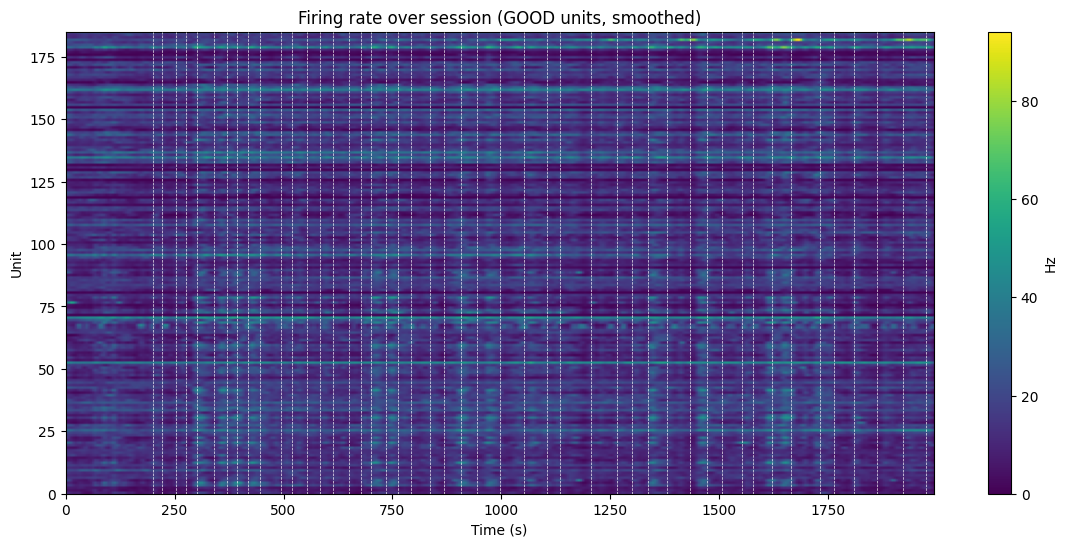

In [7]:
# =========================
# CELL: FIRING RATE (ROBUST)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---- PARAMETERS ----
bin_size = 5.0          # 👈 bigger bins (was 1.0)   ##########################################################################################################################################
SMOOTH_SIGMA = 1.0      # 👈 light smoothing         ##########################################################################################################################################
BASELINE_END = 100.0    # baseline window            ##########################################################################################################################################
THRESHOLD = 3.0         # stricter threshold         ##########################################################################################################################################

# =========================
# RECORDING DURATION
# =========================
all_spike_times = []

for unit in good_units:
    st = sorting_good.get_unit_spike_train(unit) / sf
    if len(st) > 0:
        all_spike_times.append(st[-1])

recording_duration = np.max(all_spike_times)
print(f"Recording duration: {recording_duration:.2f} sec")

# =========================
# BINNING
# =========================
bins = np.arange(0, recording_duration + bin_size, bin_size)
centers = (bins[:-1] + bins[1:]) / 2

rate_matrix = []

# =========================
# COMPUTE FIRING RATES
# =========================
for unit in good_units:

    spike_times = sorting_good.get_unit_spike_train(unit) / sf

    counts, _ = np.histogram(spike_times, bins=bins)
    rate = counts / bin_size

    # 👇 smoothing (critical)
    rate_smooth = gaussian_filter1d(rate, sigma=SMOOTH_SIGMA)

    rate_matrix.append(rate_smooth)

rate_matrix = np.array(rate_matrix)

# =========================
# BASELINE (FIRST 100s)
# =========================
baseline_mask = centers <= BASELINE_END
baseline_rates = np.mean(rate_matrix[:, baseline_mask], axis=1)

# =========================
# DETECT LARGE CHANGES (ROBUST)
# =========================
flagged_units = []

for i, unit in enumerate(good_units):

    baseline = baseline_rates[i]

    # 👇 robust stats (ignore extremes)
    high = np.percentile(rate_matrix[i], 95)
    low  = np.percentile(rate_matrix[i], 5)

    if baseline < 0.1:
        continue

    fold_up = high / baseline
    fold_down = baseline / max(low, 0.1)

    if (fold_up >= THRESHOLD) or (fold_down >= THRESHOLD):
        flagged_units.append((unit, baseline, high, low, fold_up, fold_down))

print("\n🚨 Units with large firing rate changes:")
print(f"(threshold = {THRESHOLD}x baseline)")

for u in flagged_units[:20]:
    print(f"Unit {u[0]} | baseline={u[1]:.2f} Hz | high={u[2]:.2f} | low={u[3]:.2f} | ↑x{u[4]:.2f} ↓x{u[5]:.2f}")

print(f"\nTotal flagged units: {len(flagged_units)} / {len(good_units)}")

# =========================
# PLOT HEATMAP
# =========================

plt.figure(figsize=(14,6))

plt.imshow(rate_matrix,
           aspect='auto',
           extent=[0, recording_duration, 0, len(good_units)],
           origin='lower')

plt.xlabel("Time (s)")
plt.ylabel("Unit")
plt.title("Firing rate over session (GOOD units, smoothed)")
plt.colorbar(label="Hz")

# =========================
# TTL OVERLAY (WHITE, THIN)
# =========================

if 'ttl_times' in globals():

    valid_ttls = ttl_times[
        (ttl_times >= 0) &
        (ttl_times <= recording_duration)
    ]

    for t in valid_ttls:
        plt.axvline(t,
                    linestyle='--',
                    linewidth=0.5,   # 👈 as requested
                    color='white',   # 👈 as requested
                    alpha=0.9,
                    zorder=10)

    print(f"\n✅ Overlayed {len(valid_ttls)} TTLs")

else:
    print("\n⚠️ ttl_times not found")

plt.show()

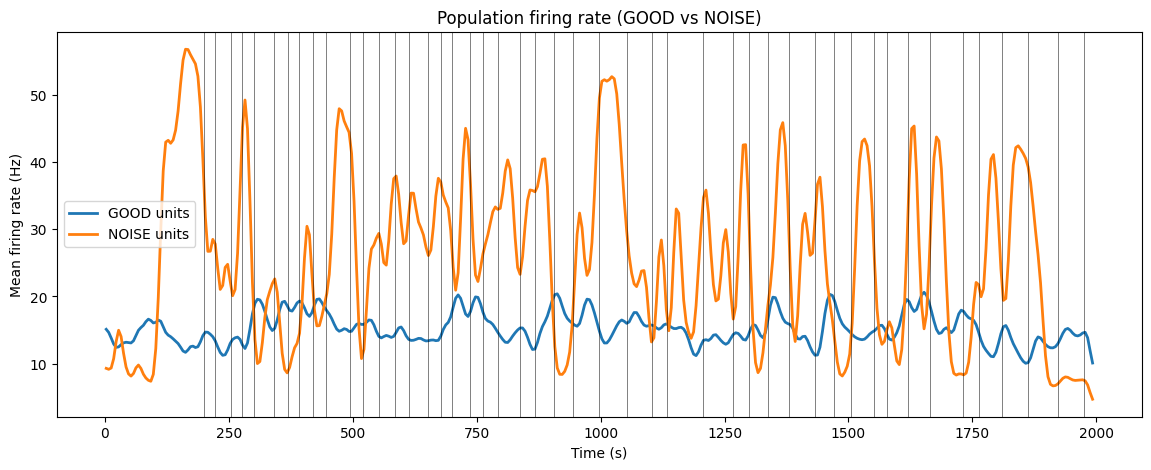

In [8]:
# =========================
# CELL: POPULATION FIRING (GOOD vs NOISE)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---- PARAMETERS ----
bin_size = 5.0
SMOOTH_SIGMA = 1.5

# =========================
# RECORDING DURATION
# =========================
all_spike_times = []

for unit in good_units:
    st = sorting_good.get_unit_spike_train(unit) / sf
    if len(st) > 0:
        all_spike_times.append(st[-1])

recording_duration = np.max(all_spike_times)

bins = np.arange(0, recording_duration + bin_size, bin_size)
centers = (bins[:-1] + bins[1:]) / 2

# =========================
# GOOD UNITS
# =========================
good_rates = []

for unit in good_units:
    spike_times = sorting_good.get_unit_spike_train(unit) / sf
    counts, _ = np.histogram(spike_times, bins=bins)
    rate = counts / bin_size
    rate = gaussian_filter1d(rate, sigma=SMOOTH_SIGMA)
    good_rates.append(rate)

good_rates = np.array(good_rates)
mean_good = np.mean(good_rates, axis=0)

# =========================
# NOISE UNITS
# =========================
noise_rates = []

for unit in noise_units:
    spike_times = sorting_noise.get_unit_spike_train(unit) / sf
    counts, _ = np.histogram(spike_times, bins=bins)
    rate = counts / bin_size
    rate = gaussian_filter1d(rate, sigma=SMOOTH_SIGMA)
    noise_rates.append(rate)

noise_rates = np.array(noise_rates)
mean_noise = np.mean(noise_rates, axis=0)

# =========================
# PLOT
# =========================
plt.figure(figsize=(14,5))

plt.plot(centers, mean_good, label="GOOD units", linewidth=2)
plt.plot(centers, mean_noise, label="NOISE units", linewidth=2)

# ---- TTL overlay ----
if 'ttl_times' in globals():
    valid_ttls = ttl_times[(ttl_times >= 0) & (ttl_times <= recording_duration)]
    for t in valid_ttls:
        plt.axvline(t, color='black', linewidth=0.5, alpha=0.7)

plt.xlabel("Time (s)")
plt.ylabel("Mean firing rate (Hz)")
plt.title("Population firing rate (GOOD vs NOISE)")
plt.legend()

plt.show()

Plotted 47 real TTLs


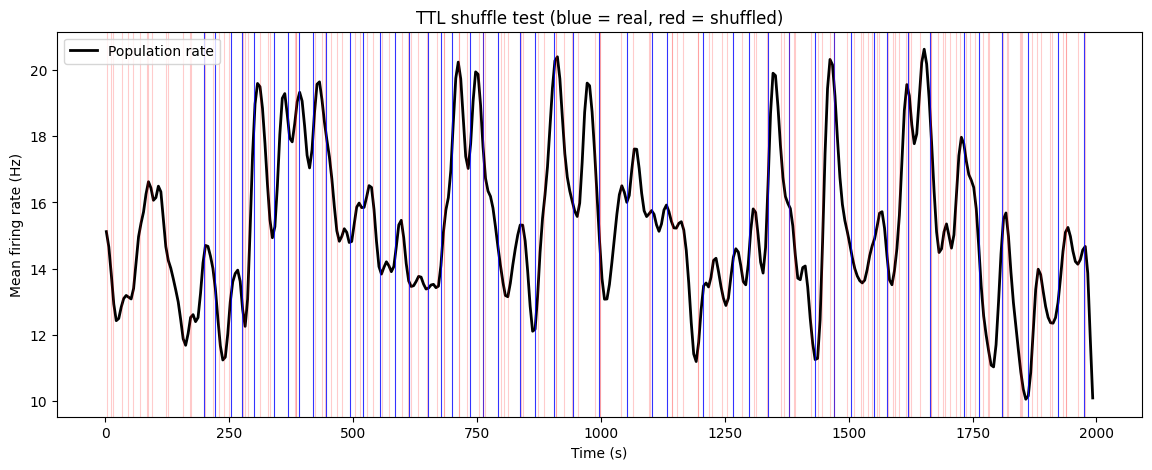

In [9]:
# =========================
# CELL: TTL SHUFFLE TEST
# =========================

import numpy as np
import matplotlib.pyplot as plt

# ---- number of shuffles ----
N_SHUFFLES = 3

plt.figure(figsize=(14,5))

# plot population activity
plt.plot(centers, mean_good, color='black', linewidth=2, label='Population rate')

# =========================
# REAL TTLs (WHITE)
# =========================
if 'ttl_times' in globals():

    valid_ttls = ttl_times[(ttl_times >= 0) & (ttl_times <= recording_duration)]

    for t in valid_ttls:
        plt.axvline(t, color='blue', linewidth=0.8, alpha=0.8)

    print(f"Plotted {len(valid_ttls)} real TTLs")

# =========================
# CIRCULAR SHIFT SHUFFLE
# =========================

for i in range(N_SHUFFLES):

    shift = np.random.uniform(0, recording_duration)

    shuffled = ttl_times + shift
    shuffled = shuffled % recording_duration  # wrap around

    for t in shuffled:
        plt.axvline(t,
                    color='red',
                    linewidth=0.8,
                    alpha=0.2)

plt.xlabel("Time (s)")
plt.ylabel("Mean firing rate (Hz)")
plt.title("TTL shuffle test (blue = real, red = shuffled)")

plt.legend()
plt.show()

Using 42 TTLs


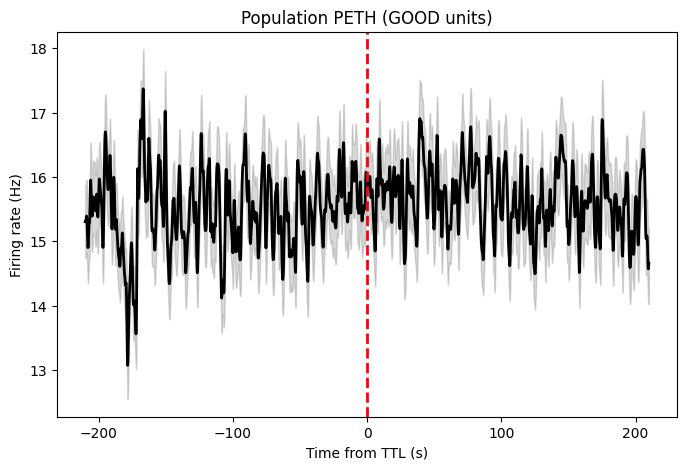


Baseline: 15.47 Hz
Post-TTL: 15.87 Hz
Change: 0.41 Hz


In [4]:
# =========================
# CELL: POPULATION PETH (GOOD UNITS)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---- PARAMETERS ----
window = [-210.0, 210.0]   # seconds around TTL
bin_size = 0.2        #  ms bins
SMOOTH_SIGMA = 1.5     # mild smoothing

# =========================
# PREP TIME AXIS
# =========================
bins = np.arange(window[0], window[1] + bin_size, bin_size)
centers = (bins[:-1] + bins[1:]) / 2

# keep only TTLs that won't clip window
valid_ttls = ttl_times[
    (ttl_times > -window[0]) &
    (ttl_times < recording_duration - window[1])
]

print(f"Using {len(valid_ttls)} TTLs")

# =========================
# COMPUTE PETH PER UNIT
# =========================
unit_peths = []

for unit in good_units:

    spike_times = sorting_good.get_unit_spike_train(unit) / sf

    all_counts = []

    for t in valid_ttls:
        aligned_spikes = spike_times - t
        counts, _ = np.histogram(aligned_spikes, bins=bins)
        all_counts.append(counts)

    if len(all_counts) == 0:
        continue

    all_counts = np.array(all_counts)

    # average across trials → firing rate
    mean_counts = np.mean(all_counts, axis=0)
    rate = mean_counts / bin_size

    # smooth
    rate = gaussian_filter1d(rate, sigma=SMOOTH_SIGMA)

    unit_peths.append(rate)

unit_peths = np.array(unit_peths)

# =========================
# POPULATION AVERAGE
# =========================
mean_peth = np.mean(unit_peths, axis=0)
sem_peth  = np.std(unit_peths, axis=0) / np.sqrt(len(unit_peths))

# =========================
# PLOT
# =========================
plt.figure(figsize=(8,5))

plt.plot(centers, mean_peth, color='black', linewidth=2)
plt.fill_between(centers,
                 mean_peth - sem_peth,
                 mean_peth + sem_peth,
                 color='gray',
                 alpha=0.3)

# TTL time
plt.axvline(0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Time from TTL (s)")
plt.ylabel("Firing rate (Hz)")
plt.title("Population PETH (GOOD units)")

plt.show()

# =========================
# PRINT SUMMARY
# =========================
baseline_mask = centers < -0.5
response_mask = (centers > 0) & (centers < 0.5)

baseline = np.mean(mean_peth[baseline_mask])
response = np.mean(mean_peth[response_mask])

print(f"\nBaseline: {baseline:.2f} Hz")
print(f"Post-TTL: {response:.2f} Hz")
print(f"Change: {response - baseline:.2f} Hz")

Using 45 shifted TTLs


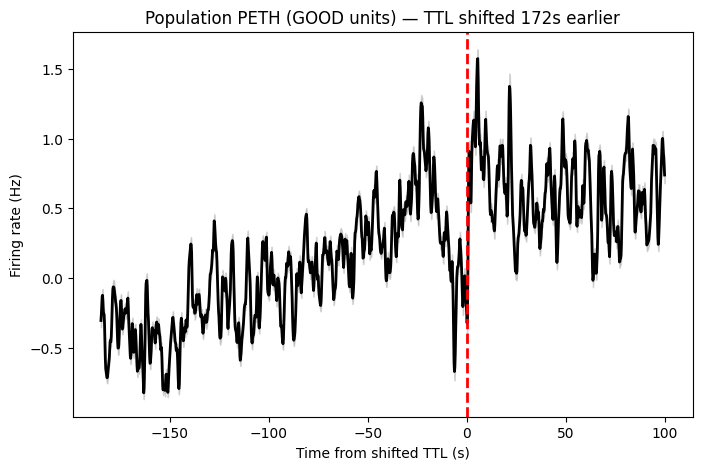


Baseline: 0.00 Hz
Post-TTL: -0.18 Hz
Change: -0.18 Hz


In [18]:
# =========================
# CELL: POPULATION PETH (GOOD UNITS)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---- PARAMETERS ----
window = [-185.0, 100.0]   # seconds around TTL
bin_size = 0.2             # seconds per bin
SMOOTH_SIGMA = 1         # mild smoothing
SHIFT = 172              # shift TTLs earlier by 172 seconds

# =========================
# PREP TIME AXIS
# =========================
bins = np.arange(window[0], window[1] + bin_size, bin_size)
centers = (bins[:-1] + bins[1:]) / 2

# keep only TTLs that won't clip window
valid_ttls = ttl_times[
    (ttl_times > -window[0]) &
    (ttl_times < recording_duration - window[1])
]

# shift TTLs earlier
valid_ttls_shifted = valid_ttls - SHIFT

print(f"Using {len(valid_ttls_shifted)} shifted TTLs")

# =========================
# COMPUTE PETH PER UNIT
# =========================
unit_peths = []

for unit in good_units:

    spike_times = sorting_good.get_unit_spike_train(unit) / sf

    all_counts = []

    for t in valid_ttls_shifted:
        aligned_spikes = spike_times - t
        counts, _ = np.histogram(aligned_spikes, bins=bins)
        all_counts.append(counts)

    if len(all_counts) == 0:
        continue

    all_counts = np.array(all_counts)

    # average across trials → firing rate
    mean_counts = np.mean(all_counts, axis=0)
    rate = mean_counts / bin_size

    # --- compute baseline stats for z-scoring ---
    baseline_mask = centers < 0
    baseline_vals = rate[baseline_mask]

    mu = np.mean(baseline_vals)
    sigma = np.std(baseline_vals)

    # avoid divide-by-zero
    if sigma == 0:
        sigma = 1e-9

    # --- z-score the entire rate trace ---
    z_rate = (rate - mu) / sigma

    # smooth
    z_rate = gaussian_filter1d(z_rate, sigma=SMOOTH_SIGMA)

    unit_peths.append(z_rate)


# =========================
# POPULATION AVERAGE
# =========================
mean_peth = np.mean(unit_peths, axis=0)
sem_peth  = np.std(unit_peths, axis=0) / np.sqrt(len(unit_peths))

# =========================
# PLOT
# =========================
plt.figure(figsize=(8,5))

plt.plot(centers, mean_peth, color='black', linewidth=2)
plt.fill_between(centers,
                 mean_peth - sem_peth,
                 mean_peth + sem_peth,
                 color='gray',
                 alpha=0.3)

# TTL time (still at 0 because alignment is shifted)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Time from shifted TTL (s)")
plt.ylabel("Firing rate (Hz)")
plt.title("Population PETH (GOOD units) — TTL shifted 172s earlier")

plt.show()

# =========================
# PRINT SUMMARY
# =========================
baseline_mask = centers < -0.5
response_mask = (centers > 0) & (centers < 0.5)

baseline = np.mean(mean_peth[baseline_mask])
response = np.mean(mean_peth[response_mask])

print(f"\nBaseline: {baseline:.2f} Hz")
print(f"Post-TTL: {response:.2f} Hz")
print(f"Change: {response - baseline:.2f} Hz")


Using 46 shifted TTLs


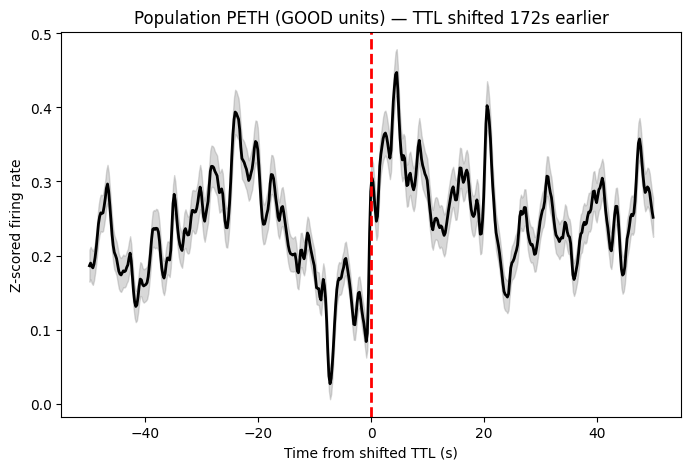


Baseline: 0.22
Post-TTL: 0.30
Change: 0.08


In [25]:
# =========================
# CELL: POPULATION PETH (GOOD UNITS) Z score of initial baselien for each unit
# =========================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---- PARAMETERS ----
window = [-50.0, 50.0]       # seconds around TTL (updated)
bin_size = 0.2             # seconds per bin
SMOOTH_SIGMA = 1           # mild smoothing
SHIFT = 171                # shift TTLs earlier by 172 seconds

# ---- GLOBAL BASELINE WINDOW (SESSION TIME) ----
BASELINE_START = 120.0     # seconds in session
BASELINE_END   = 180.0     # seconds in session

# Precompute baseline bins
baseline_bins = np.arange(BASELINE_START,
                          BASELINE_END + bin_size,
                          bin_size)

# =========================
# PREP TIME AXIS
# =========================
bins = np.arange(window[0], window[1] + bin_size, bin_size)
centers = (bins[:-1] + bins[1:]) / 2

# keep only TTLs that won't clip window
valid_ttls = ttl_times[
    (ttl_times > -window[0]) &
    (ttl_times < recording_duration - window[1])
]

# shift TTLs earlier
valid_ttls_shifted = valid_ttls - SHIFT

print(f"Using {len(valid_ttls_shifted)} shifted TTLs")

# =========================
# COMPUTE PETH PER UNIT
# =========================
unit_peths = []

for unit in good_units:

    spike_times = sorting_good.get_unit_spike_train(unit) / sf

    # --- GLOBAL BASELINE FROM SESSION (120–180 s) ---
    baseline_counts, _ = np.histogram(spike_times, bins=baseline_bins)
    baseline_rate = baseline_counts / bin_size

    mu = np.mean(baseline_rate)
    sigma = np.std(baseline_rate)
    if sigma == 0:
        sigma = 1e-9

    # --- build PETH ---
    all_counts = []

    for t in valid_ttls_shifted:
        aligned_spikes = spike_times - t
        counts, _ = np.histogram(aligned_spikes, bins=bins)
        all_counts.append(counts)

    if len(all_counts) == 0:
        continue

    all_counts = np.array(all_counts)

    # average across trials → firing rate
    mean_counts = np.mean(all_counts, axis=0)
    rate = mean_counts / bin_size

    # --- z-score using GLOBAL baseline ---
    z_rate = (rate - mu) / sigma

    # smooth
    z_rate = gaussian_filter1d(z_rate, sigma=SMOOTH_SIGMA)

    unit_peths.append(z_rate)

# =========================
# POPULATION AVERAGE
# =========================
mean_peth = np.mean(unit_peths, axis=0)
sem_peth  = np.std(unit_peths, axis=0) / np.sqrt(len(unit_peths))

# =========================
# PLOT
# =========================
plt.figure(figsize=(8,5))

plt.plot(centers, mean_peth, color='black', linewidth=2)
plt.fill_between(centers,
                 mean_peth - sem_peth,
                 mean_peth + sem_peth,
                 color='gray',
                 alpha=0.3)

# TTL time (still at 0 because alignment is shifted)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Time from shifted TTL (s)")
plt.ylabel("Z-scored firing rate")
plt.title("Population PETH (GOOD units) — TTL shifted 172s earlier")

plt.show()

# =========================
# PRINT SUMMARY
# =========================
baseline_mask = centers < -0.5
response_mask = (centers > 0) & (centers < 0.5)

baseline = np.mean(mean_peth[baseline_mask])
response = np.mean(mean_peth[response_mask])

print(f"\nBaseline: {baseline:.2f}")
print(f"Post-TTL: {response:.2f}")
print(f"Change: {response - baseline:.2f}")


Total units: 390
Good units: 100
Other units: 290


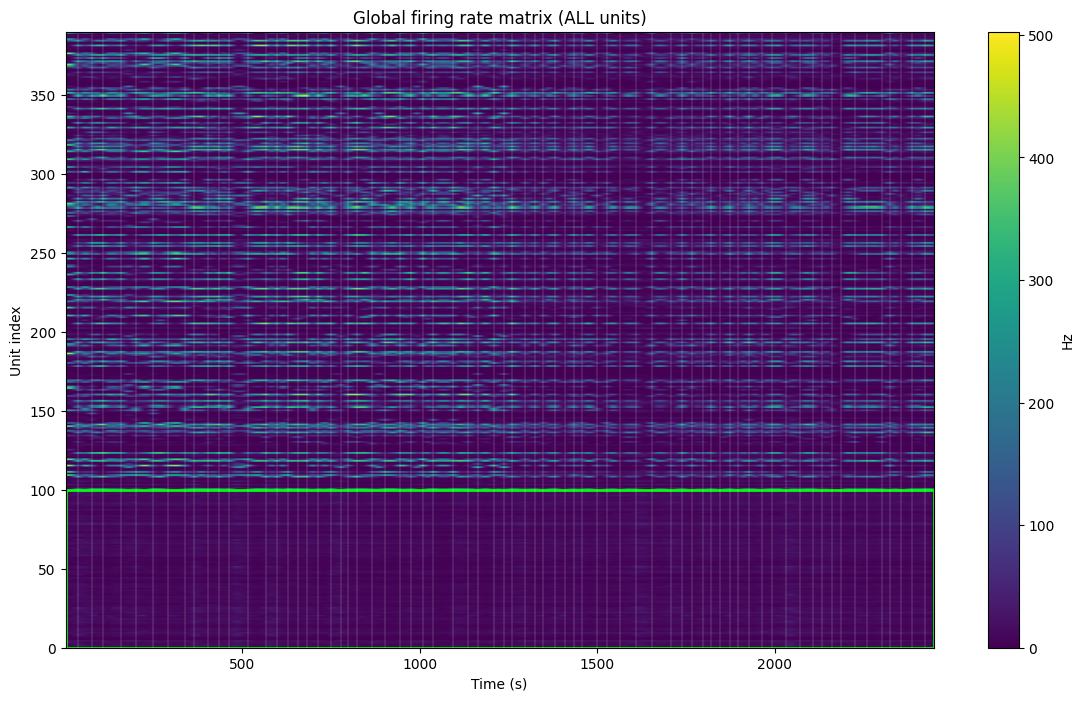

In [23]:
# =========================
# CELL: GLOBAL FIRING MATRIX (ALL UNITS)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---- PARAMETERS ----
bin_size = 5.0
SMOOTH_SIGMA = 1.5

# =========================
# ALL UNITS
# =========================
all_units = sorting.get_unit_ids()

# separate groups
good_set = set(good_units)
other_units = [u for u in all_units if u not in good_set]

# stack: GOOD on top, others below
ordered_units = good_units + other_units

print(f"Total units: {len(ordered_units)}")
print(f"Good units: {len(good_units)}")
print(f"Other units: {len(other_units)}")

# =========================
# RECORDING DURATION
# =========================
all_spike_times = []

for unit in ordered_units:
    st = sorting.get_unit_spike_train(unit) / sf
    if len(st) > 0:
        all_spike_times.append(st[-1])

recording_duration = np.max(all_spike_times)

# =========================
# BINNING
# =========================
bins = np.arange(0, recording_duration + bin_size, bin_size)
centers = (bins[:-1] + bins[1:]) / 2

# =========================
# BUILD MATRIX
# =========================
rate_matrix = []

for unit in ordered_units:

    spike_times = sorting.get_unit_spike_train(unit) / sf

    counts, _ = np.histogram(spike_times, bins=bins)
    rate = counts / bin_size

    # smooth
    rate = gaussian_filter1d(rate, sigma=SMOOTH_SIGMA)

    rate_matrix.append(rate)

rate_matrix = np.array(rate_matrix)

# =========================
# PLOT
# =========================
plt.figure(figsize=(14,8))

im = plt.imshow(rate_matrix,
                aspect='auto',
                origin='lower',
                extent=[centers[0], centers[-1], 0, len(ordered_units)])

plt.colorbar(im, label="Hz")

# =========================
# GREEN BOX FOR GOOD UNITS
# =========================
n_good = len(good_units)

plt.hlines([0, n_good], xmin=centers[0], xmax=centers[-1],
           colors='lime', linewidth=2)

plt.vlines([centers[0], centers[-1]], ymin=0, ymax=n_good,
           colors='lime', linewidth=2)

# =========================
# TTL OVERLAY (OPTIONAL)
# =========================
if 'ttl_times' in globals():

    valid_ttls = ttl_times[
        (ttl_times >= 0) &
        (ttl_times <= recording_duration)
    ]

    for t in valid_ttls:
        plt.axvline(t,
                    color='white',
                    linewidth=0.3,
                    alpha=0.5)

# =========================
# LABELS
# =========================
plt.xlabel("Time (s)")
plt.ylabel("Unit index")
plt.title("Global firing rate matrix (ALL units)")

plt.show()

Total units: 437
Good units: 185
Other units: 252


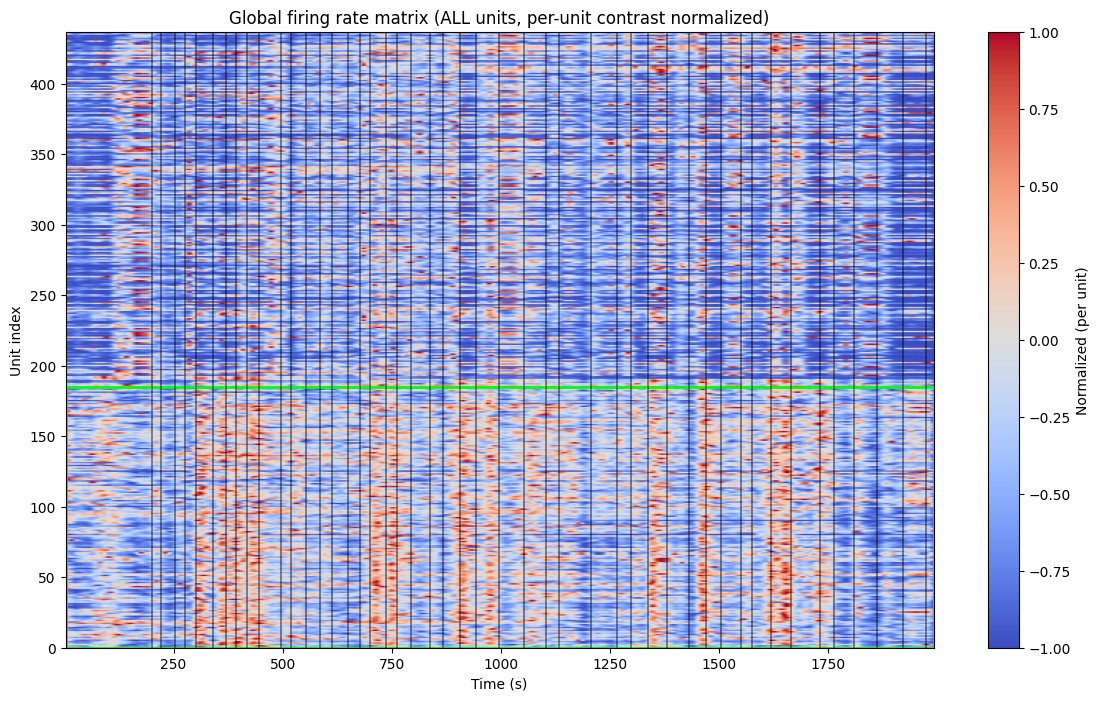

In [5]:
# =========================
# CELL: GLOBAL FIRING MATRIX (ALL UNITS, PER-UNIT CONTRAST NORMALIZED)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---- PARAMETERS ----
bin_size = 5.0
SMOOTH_SIGMA = 1.5

# =========================
# ALL UNITS
# =========================
all_units = sorting.get_unit_ids()

good_set = set(good_units)
other_units = [u for u in all_units if u not in good_set]

ordered_units = good_units + other_units

print(f"Total units: {len(ordered_units)}")
print(f"Good units: {len(good_units)}")
print(f"Other units: {len(other_units)}")

# =========================
# RECORDING DURATION
# =========================
all_spike_times = []

for unit in ordered_units:
    st = sorting.get_unit_spike_train(unit) / sf
    if len(st) > 0:
        all_spike_times.append(st[-1])

recording_duration = np.max(all_spike_times)

# =========================
# BINNING
# =========================
bins = np.arange(0, recording_duration + bin_size, bin_size)
centers = (bins[:-1] + bins[1:]) / 2

# =========================
# BUILD MATRIX (PER-UNIT CONTRAST NORMALIZATION)
# =========================
rate_matrix = []

for unit in ordered_units:

    spike_times = sorting.get_unit_spike_train(unit) / sf

    counts, _ = np.histogram(spike_times, bins=bins)
    rate = counts / bin_size

    # smooth
    rate = gaussian_filter1d(rate, sigma=SMOOTH_SIGMA)

    # =========================
    # 🔥 PER-UNIT MIN-MAX → [-1, 1]
    # =========================
    r_min = np.min(rate)
    r_max = np.max(rate)

    if (r_max - r_min) < 1e-6:
        rate_norm = np.zeros_like(rate)
    else:
        rate_norm = 2 * (rate - r_min) / (r_max - r_min) - 1

    rate_matrix.append(rate_norm)

rate_matrix = np.array(rate_matrix)

# =========================
# PLOT
# =========================
plt.figure(figsize=(14,8))

im = plt.imshow(rate_matrix,
                aspect='auto',
                origin='lower',
                extent=[centers[0], centers[-1], 0, len(ordered_units)],
                vmin=-1,
                vmax=1,
                cmap='coolwarm')

plt.colorbar(im, label="Normalized (per unit)")

# =========================
# GREEN BOX FOR GOOD UNITS
# =========================
n_good = len(good_units)

plt.hlines([0, n_good], xmin=centers[0], xmax=centers[-1],
           colors='lime', linewidth=2)

plt.vlines([centers[0], centers[-1]], ymin=0, ymax=n_good,
           colors='lime', linewidth=2)

# =========================
# TTL OVERLAY
# =========================
if 'ttl_times' in globals():

    valid_ttls = ttl_times[
        (ttl_times >= 0) &
        (ttl_times <= recording_duration)
    ]

    for t in valid_ttls:
        plt.axvline(t,
                    color='black',
                    linewidth=1.2,
                    alpha=0.5)

# =========================
# LABELS
# =========================
plt.xlabel("Time (s)")
plt.ylabel("Unit index")
plt.title("Global firing rate matrix (ALL units, per-unit contrast normalized)")

plt.show()

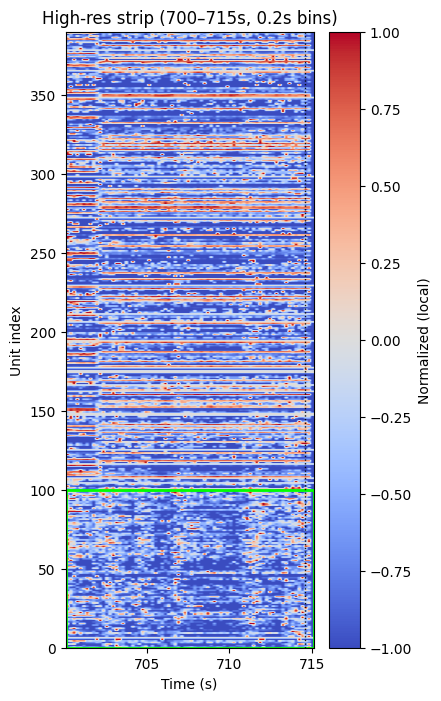

In [25]:
# =========================
# LOCAL HIGH-RES STRIP (NO SMOOTHING)
# =========================

import numpy as np
import matplotlib.pyplot as plt

# ---- PARAMETERS ----
t_start = 700
t_end   = 715
bin_size = 0.2   # 👈 go even finer here (0.5s or 0.2s)

# =========================
# ALL UNITS (same ordering)
# =========================
all_units = sorting.get_unit_ids()

good_set = set(good_units)
other_units = [u for u in all_units if u not in good_set]
ordered_units = good_units + other_units

# =========================
# BINNING (LOCAL ONLY)
# =========================
bins = np.arange(t_start, t_end + bin_size, bin_size)
centers = (bins[:-1] + bins[1:]) / 2

# =========================
# BUILD MATRIX (LOCAL WINDOW ONLY)
# =========================
rate_matrix = []

for unit in ordered_units:

    spike_times = sorting.get_unit_spike_train(unit) / sf

    # 👇 ONLY keep spikes in window (faster)
    spike_times = spike_times[
        (spike_times >= t_start) &
        (spike_times <= t_end)
    ]

    counts, _ = np.histogram(spike_times, bins=bins)
    rate = counts / bin_size

    rate_matrix.append(rate)

rate_matrix = np.array(rate_matrix)

# =========================
# PER-UNIT NORMALIZATION [-1, 1] (LOCAL WINDOW)
# =========================
rate_norm = np.zeros_like(rate_matrix)

for i in range(rate_matrix.shape[0]):
    r = rate_matrix[i]

    r_min = np.min(r)
    r_max = np.max(r)

    if r_max - r_min > 0:
        r_scaled = 2 * (r - r_min) / (r_max - r_min) - 1
    else:
        r_scaled = np.zeros_like(r)

    rate_norm[i] = r_scaled

# =========================
# PLOT (THIN STRIP)
# =========================
plt.figure(figsize=(4,8))  # 👈 thin strip

im = plt.imshow(rate_norm,
                aspect='auto',
                origin='lower',
                extent=[centers[0], centers[-1], 0, len(ordered_units)],
                vmin=-1, vmax=1,
                cmap='coolwarm')

plt.colorbar(im, label="Normalized (local)")

# =========================
# GOOD UNIT BOX
# =========================
n_good = len(good_units)

plt.hlines([0, n_good],
           xmin=centers[0],
           xmax=centers[-1],
           colors='lime', linewidth=2)

plt.vlines([centers[0], centers[-1]],
           ymin=0, ymax=n_good,
           colors='lime', linewidth=2)

# =========================
# TTL OVERLAY (LOCAL)
# =========================
if 'ttl_times' in globals():

    valid_ttls = ttl_times[
        (ttl_times >= t_start) &
        (ttl_times <= t_end)
    ]

    for t in valid_ttls:
        plt.axvline(t,
                    color='black',
                    linestyle=':',
                    linewidth=1,
                    alpha=0.9,
                    zorder=10)

# =========================
# LABELS
# =========================
plt.xlabel("Time (s)")
plt.ylabel("Unit index")
plt.title(f"High-res strip ({t_start}–{t_end}s, {bin_size}s bins)")

plt.show()